<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Scatter Plot**


Estimated time needed: **45** minutes


## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#### Step 1: Load the dataset


In [2]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)



### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




null values before cleaning 35987
null values after cleaning 0


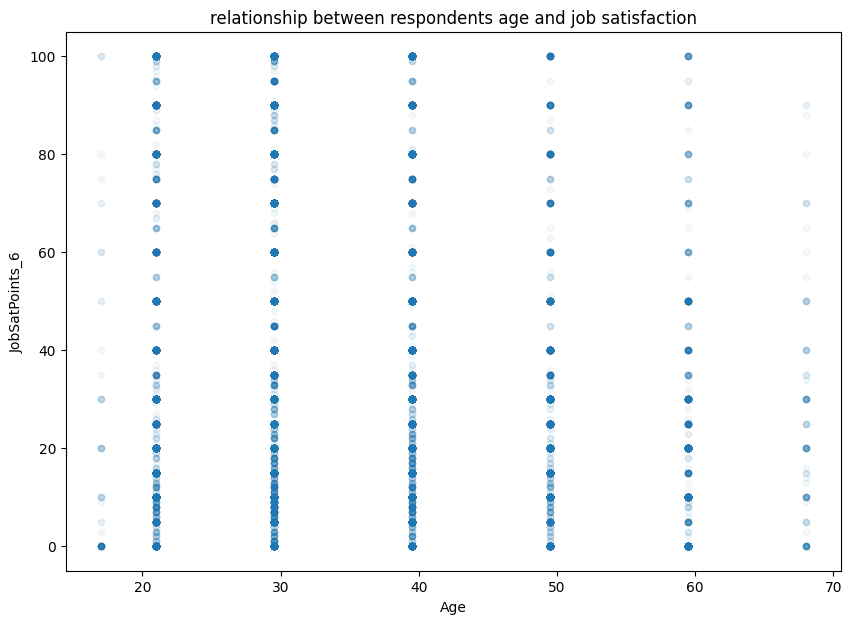

In [3]:
## Write your code here

age_sat=df.copy()

print('null values before cleaning',age_sat['JobSatPoints_6'].isnull().sum())
age_sat=age_sat.dropna(subset=['JobSatPoints_6'], axis=0)
print('null values after cleaning',age_sat['JobSatPoints_6'].isnull().sum())

age_sat=age_sat[age_sat['Age']!="Prefer not to say"]

age_sat['Age']=age_sat['Age'].replace({                      # Convert age categories to approximate midpoint values for numerical analysis
    'Under 18 years old':17
    ,'18-24 years old':21
    ,'25-34 years old':29.5
    ,'35-44 years old':39.5
    ,'45-54 years old':49.5
    ,'55-64 years old':59.5
    ,'65 years or older':68
})

age_sat['Age']=pd.to_numeric(age_sat['Age'],errors='coerce')
age_sat = age_sat.dropna(subset=['Age'], axis=0)

age_sat.plot(kind='scatter'
             ,x='Age'
             ,y='JobSatPoints_6'
             ,alpha=0.05
             , figsize=(10,7)
             ,title='relationship between respondents age and job satisfaction'
            )
plt.show()

#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


null values before cleaning

 JobSatPoints_6         35987
ConvertedCompYearly    42002
dtype: int64



null values after cleaning

 JobSatPoints_6         0
ConvertedCompYearly    0
dtype: int64

compensation skewness before limiting data 46.183865160468564

compensation skewness after limiting data 1.1381293206077323


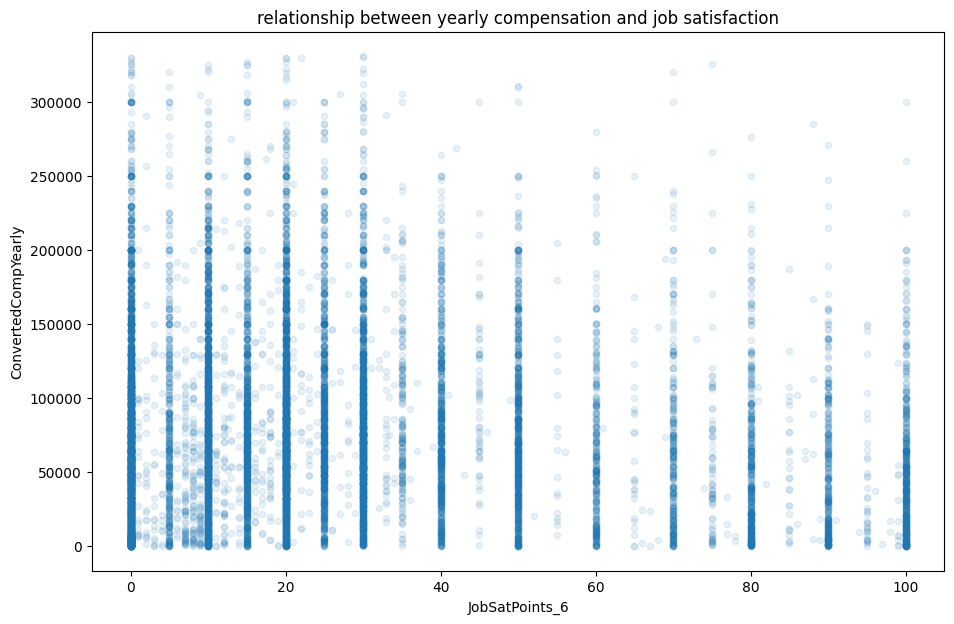

In [4]:
## Write your code here

comp_sat=df.copy()

print('null values before cleaning\n\n',comp_sat[['JobSatPoints_6','ConvertedCompYearly']].isnull().sum())
comp_sat=comp_sat.dropna(subset=['JobSatPoints_6','ConvertedCompYearly'], axis=0)
print('\n\n\nnull values after cleaning\n\n',comp_sat[['JobSatPoints_6','ConvertedCompYearly']].isnull().sum())

Q1=np.quantile(comp_sat['ConvertedCompYearly'], 0.25)
Q3=np.quantile(comp_sat['ConvertedCompYearly'], 0.75)
IQR=Q3-Q1

print('\ncompensation skewness before limiting data',comp_sat['ConvertedCompYearly'].skew())

max_value=Q3+3*IQR                                               # IQR multiplication raised to 3 because compensation data is usually right skewed
min_value=Q1-1.5*IQR

comp_sat=comp_sat[
                    (comp_sat['ConvertedCompYearly']>min_value)  # Extreme compensation values were removed using the IQR method to improve visualization clarity
                    & (comp_sat['ConvertedCompYearly']<max_value)
]

print('\ncompensation skewness after limiting data',comp_sat['ConvertedCompYearly'].skew())

comp_sat.plot(kind='scatter'
              ,x='JobSatPoints_6'
              ,y='ConvertedCompYearly'
              ,alpha=0.1
              ,figsize=(11,7)
              ,title='relationship between yearly compensation and job satisfaction'
             )
plt.show()

### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


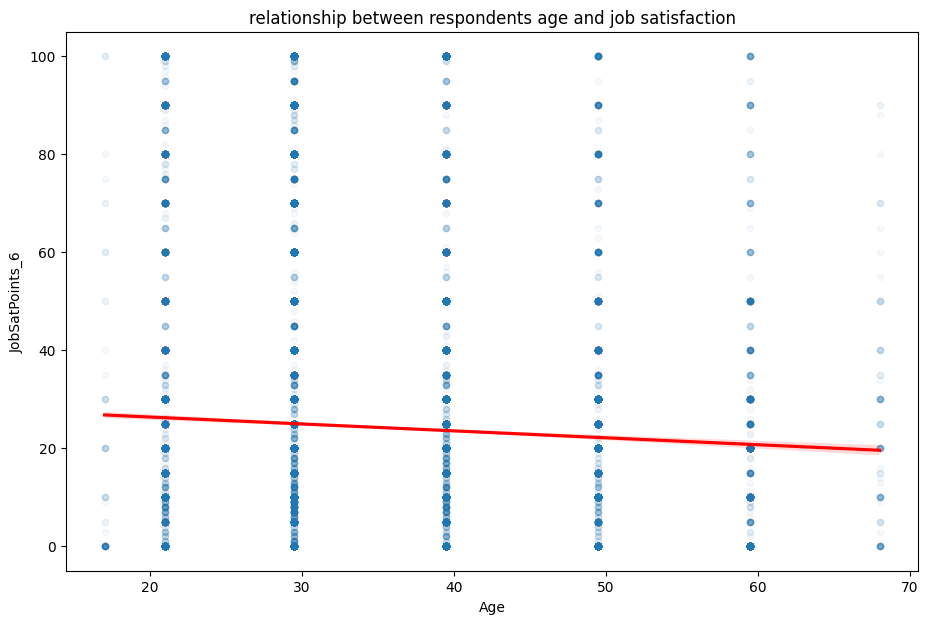

In [5]:
## Write your code here

plt.figure(figsize=(11,7))
sns.regplot(
    data=age_sat
    ,x='Age'
    ,y='JobSatPoints_6'
    ,line_kws={'color':'red'}
    ,scatter_kws={
        's':20
        ,'alpha':0.04
    }
)
plt.title('relationship between respondents age and job satisfaction')
plt.show()

#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


null values before cleaning 13827
null values after cleaning 0


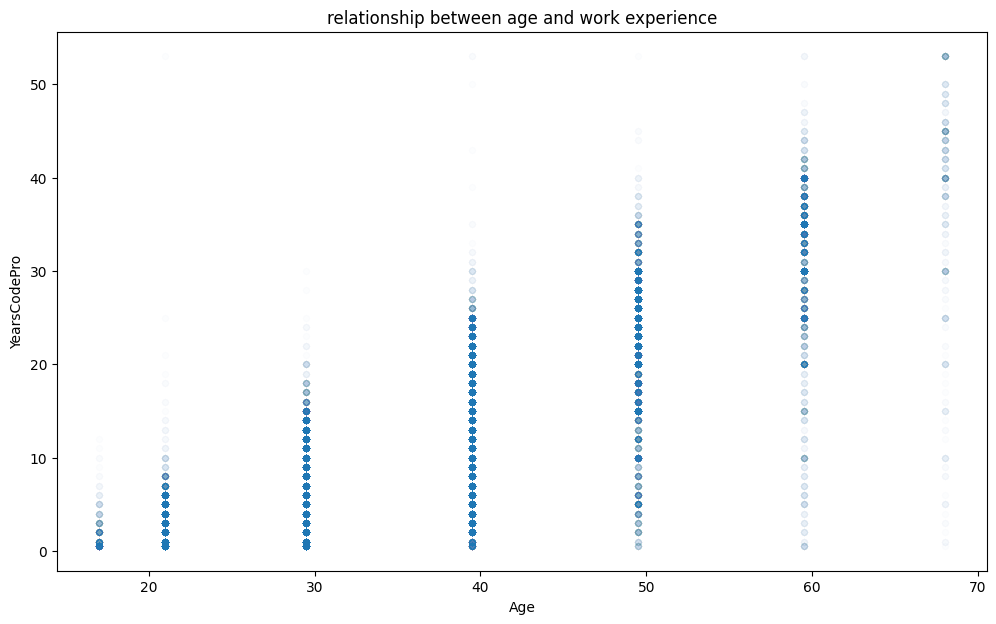

In [6]:
## Write your code here

age_exp=df.copy()

print('null values before cleaning',age_exp['YearsCodePro'].isnull().sum())
age_exp=age_exp.dropna(subset=['YearsCodePro'], axis=0)
print('null values after cleaning',age_exp['YearsCodePro'].isnull().sum())

age_exp=age_exp[age_exp['Age']!="Prefer not to say"]

age_exp['Age']=age_exp['Age'].replace({                        # Convert categorical edge values into approximate numeric representations
    'Under 18 years old':17
    ,'18-24 years old':21
    ,'25-34 years old':29.5
    ,'35-44 years old':39.5
    ,'45-54 years old':49.5
    ,'55-64 years old':59.5
    ,'65 years or older':68
})

age_exp['YearsCodePro']=age_exp['YearsCodePro'].replace({
    'Less than 1 year': 0.5
    ,'More than 50 years': 53
})

age_exp['YearsCodePro']=pd.to_numeric(age_exp['YearsCodePro'], errors='coerce')
age_exp['Age']=pd.to_numeric(age_exp['Age'],errors='coerce')
age_exp = age_exp.dropna(subset=['Age', 'YearsCodePro'], axis=0)

age_exp.plot(kind='scatter'
             ,x='Age'
             ,y='YearsCodePro'
             ,alpha=0.01
             ,figsize=(12,7)
             ,title='relationship between age and work experience'
            )
plt.show()

The visualization should be improved by removing outliers. There are clear inconsistencies in the data, such as people under 30 reporting over 20 years of work experience

### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


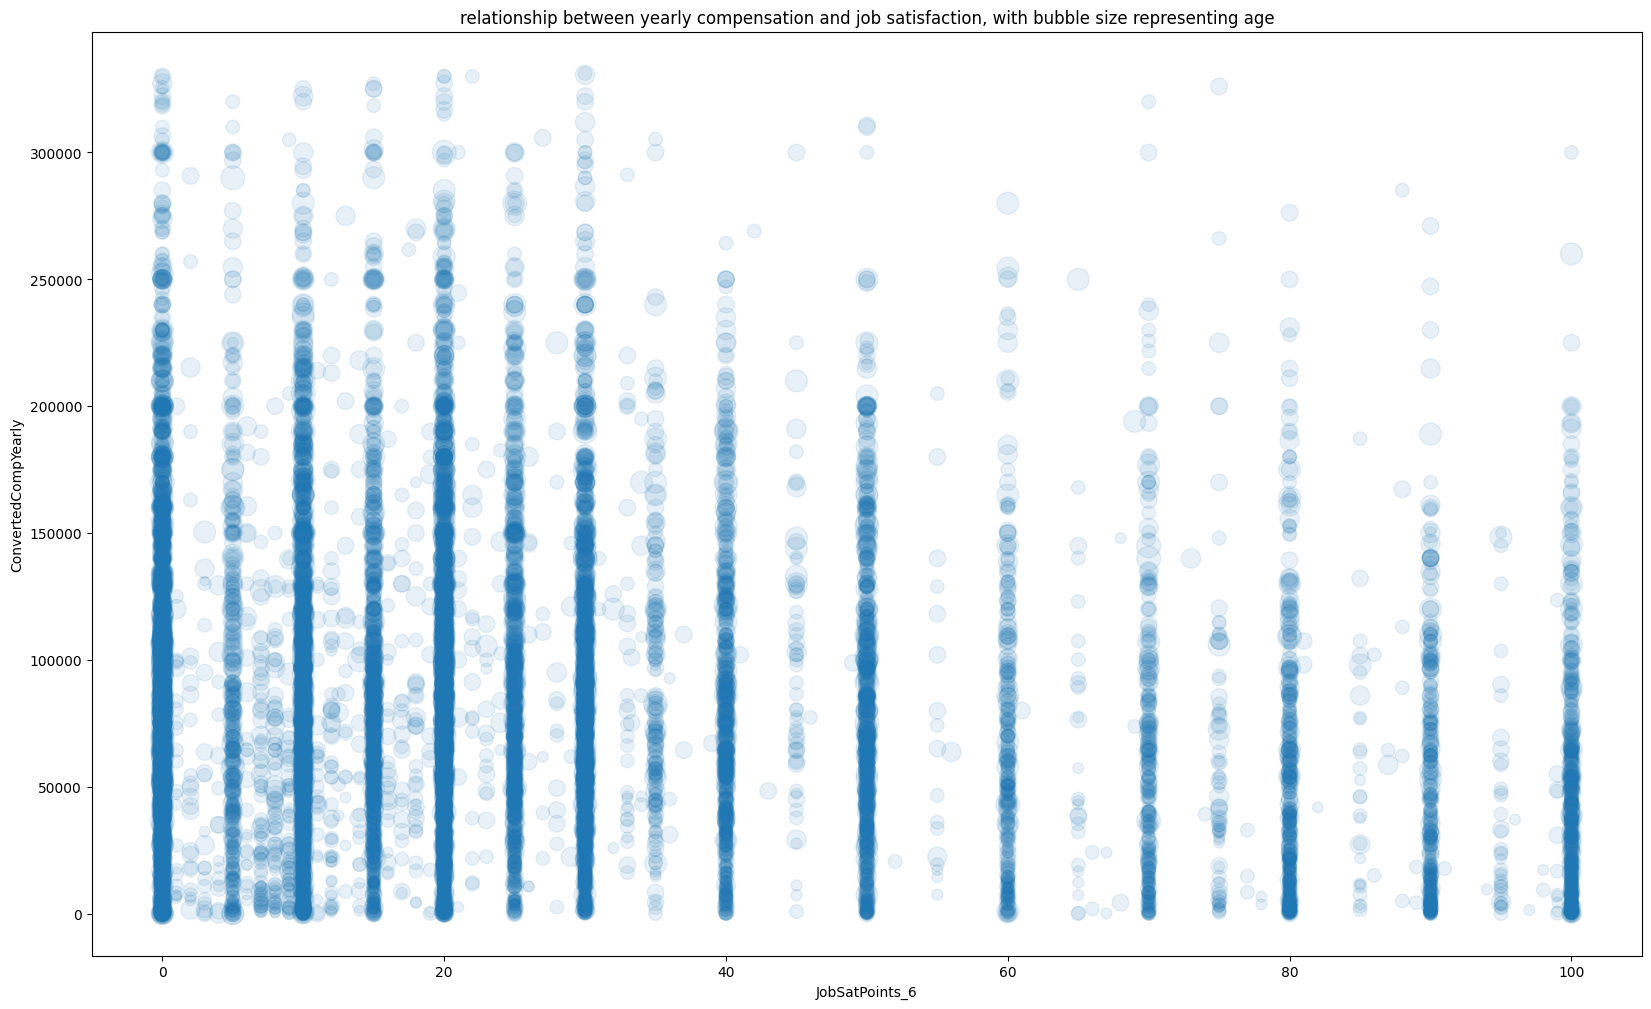

In [7]:
age_comp_sat=comp_sat[comp_sat['Age']!="Prefer not to say"].copy()

age_comp_sat['Age']=age_comp_sat['Age'].replace({
    'Under 18 years old':17
    ,'18-24 years old':21
    ,'25-34 years old':29.5
    ,'35-44 years old':39.5
    ,'45-54 years old':49.5
    ,'55-64 years old':59.5
    ,'65 years or older':68
})

age_comp_sat['Age']=pd.to_numeric(age_comp_sat['Age'],errors='coerce')

age_comp_sat = age_comp_sat.dropna(subset=['Age'], axis=0)

age_comp_sat.plot(
    kind='scatter'
    ,x='JobSatPoints_6'
    ,y='ConvertedCompYearly'
    ,s=age_comp_sat['Age']**1.35
    ,alpha=0.1
    ,figsize=(20,12)
    ,title='relationship between yearly compensation and job satisfaction, with bubble size representing age'
)
plt.show()

#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


In [8]:
## Write your code here
lang_sat=df.copy()

print('null values before cleaning\n\n',lang_sat[['JobSatPoints_6','LanguageHaveWorkedWith']].isnull().sum())
lang_sat=lang_sat.dropna(subset=['JobSatPoints_6','LanguageHaveWorkedWith'], axis=0)
print('\n\n\nnull values after cleaning\n\n',lang_sat[['JobSatPoints_6','LanguageHaveWorkedWith']].isnull().sum())

lang_sat['language']=lang_sat['LanguageHaveWorkedWith'].str.split(';')
lang_sat=lang_sat.explode('language')

top15=(
    lang_sat.groupby('language').size()
    .sort_values(ascending=False).head(15).rename('count')
)      

lang_sat=lang_sat[lang_sat['language'].isin(top15.index)]

lang_sat=lang_sat.groupby('language')['JobSatPoints_6'].mean()

lang_sat_final=pd.concat([lang_sat,top15], axis=1).sort_values('JobSatPoints_6').reset_index()

lang_sat_final.head(20)

null values before cleaning

 JobSatPoints_6            35987
LanguageHaveWorkedWith     5692
dtype: int64



null values after cleaning

 JobSatPoints_6            0
LanguageHaveWorkedWith    0
dtype: int64


,language,JobSatPoints_6,count
0,Rust,22.222817,3550
1,Go,22.883947,4373
2,Python,22.974692,14450
3,Bash/Shell (all shells),23.237911,10795
4,C,23.503650,4953
5,C++,23.921340,5867
6,PowerShell,24.418926,4499
7,C#,24.760905,8627
8,SQL,24.889480,16233
9,JavaScript,24.932811,18673


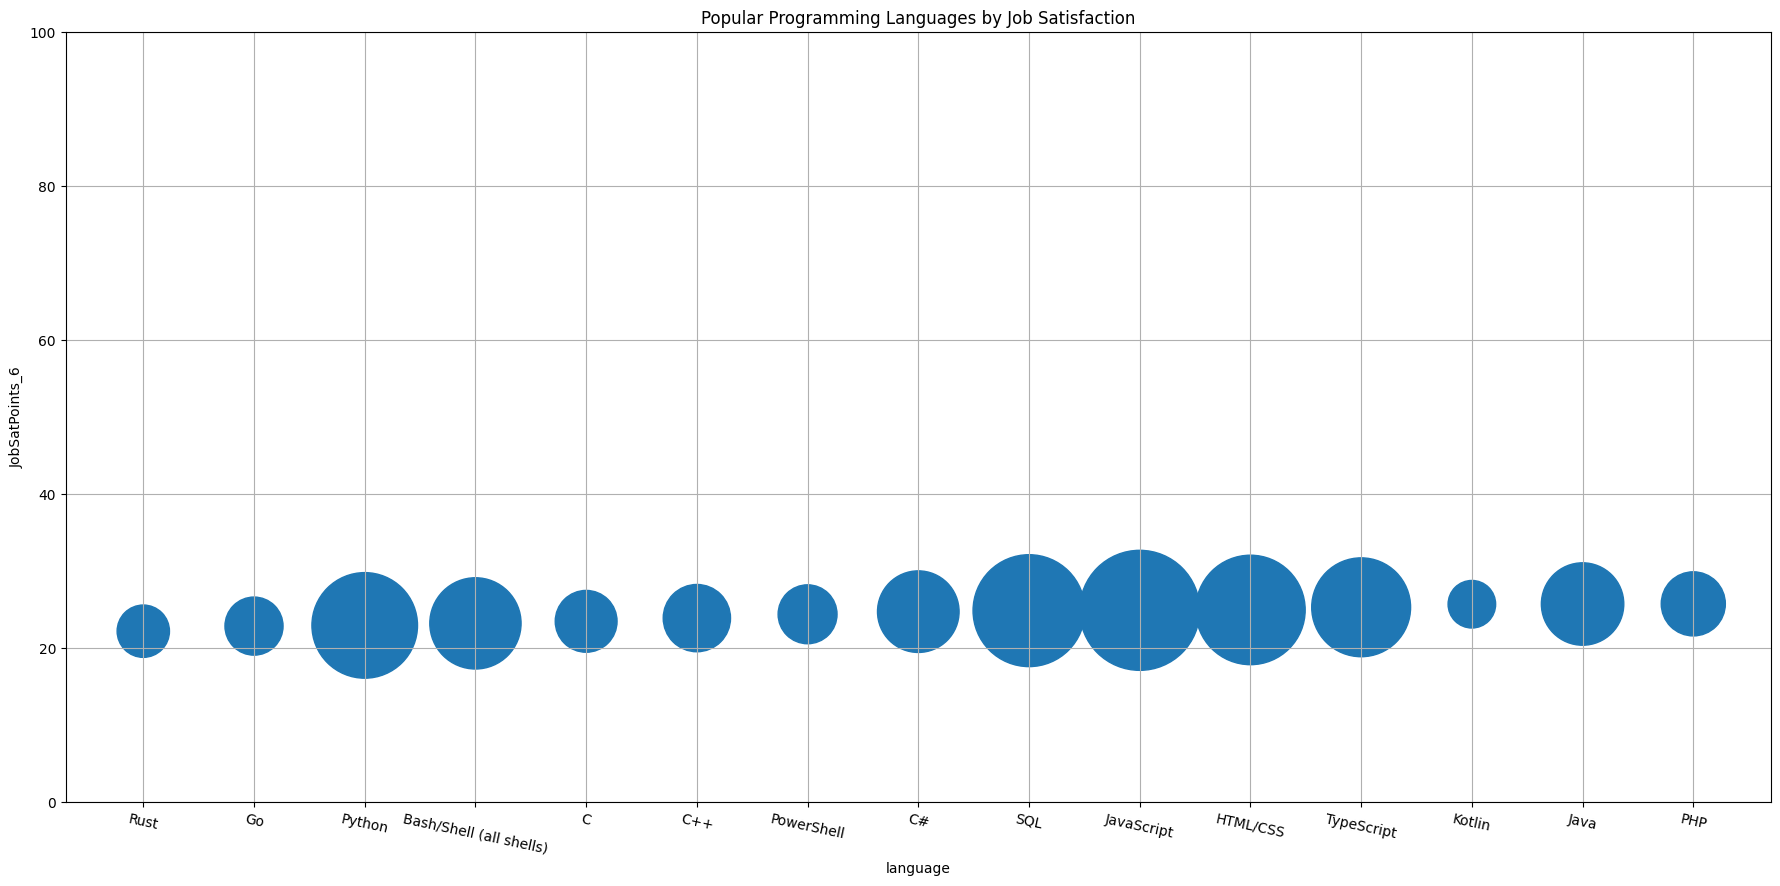

In [9]:
lang_sat_final.plot(
    kind='scatter'
    ,x='language'
    ,y='JobSatPoints_6'
    ,s=lang_sat_final['count']/2.5
    ,ylim=(0,100)
    ,figsize=(22,10)
    ,grid=True
    ,title='Popular Programming Languages by Job Satisfaction'
)
plt.xticks(rotation=-12)
plt.show()

### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


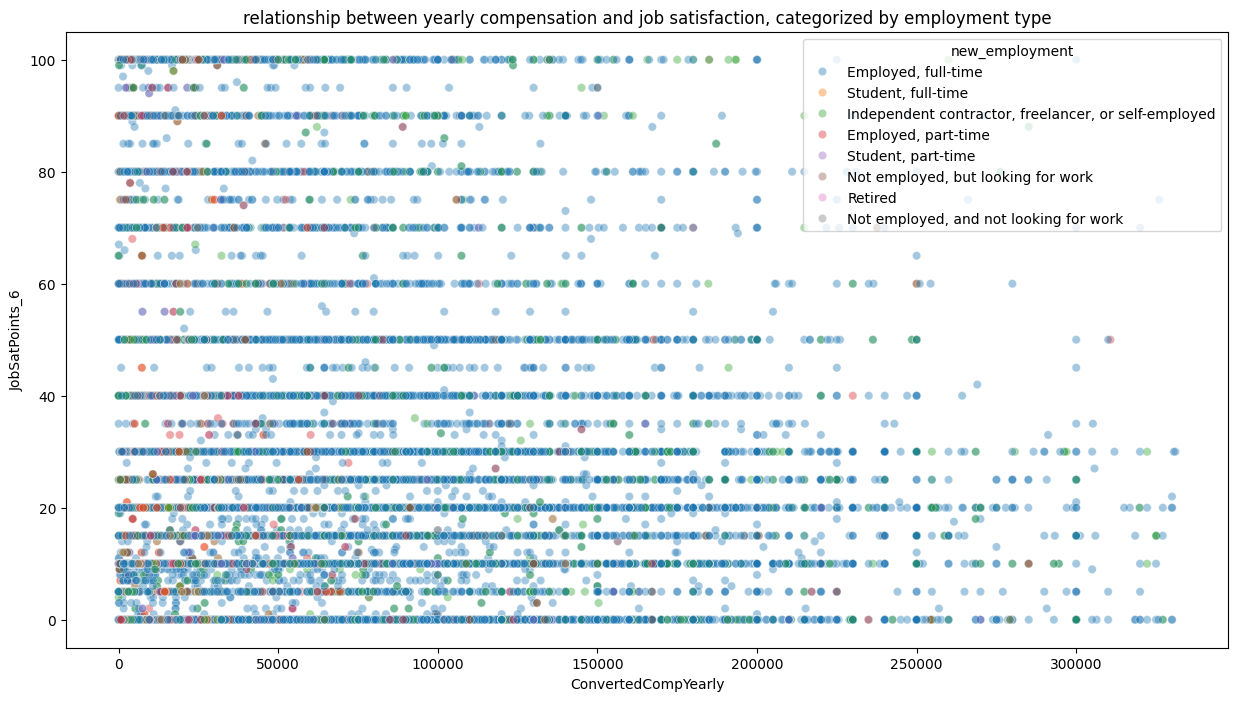

In [10]:
## Write your code here

comp_sat_emp=comp_sat.copy()

comp_sat_emp['new_employment']=comp_sat_emp['Employment'].str.split(';')
comp_sat_emp=comp_sat_emp.explode('new_employment')

top10=(comp_sat_emp.groupby('new_employment').size()
       .sort_values(ascending=False).head(10).index
      )
comp_sat_emp=comp_sat_emp[comp_sat_emp['new_employment'].isin(top10)]

plt.figure(figsize=(15,8))
sns.scatterplot(data=comp_sat_emp
            , x='ConvertedCompYearly' 
            , y='JobSatPoints_6'
            , hue='new_employment'
            , alpha=0.4
           )
plt.title('relationship between yearly compensation and job satisfaction, categorized by employment type')
plt.show()

#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different age groups and markers for countries.


null values before cleaning Country          6507
YearsCodePro    13827
dtype: int64


null values after cleaning Country         0
YearsCodePro    0
dtype: int64


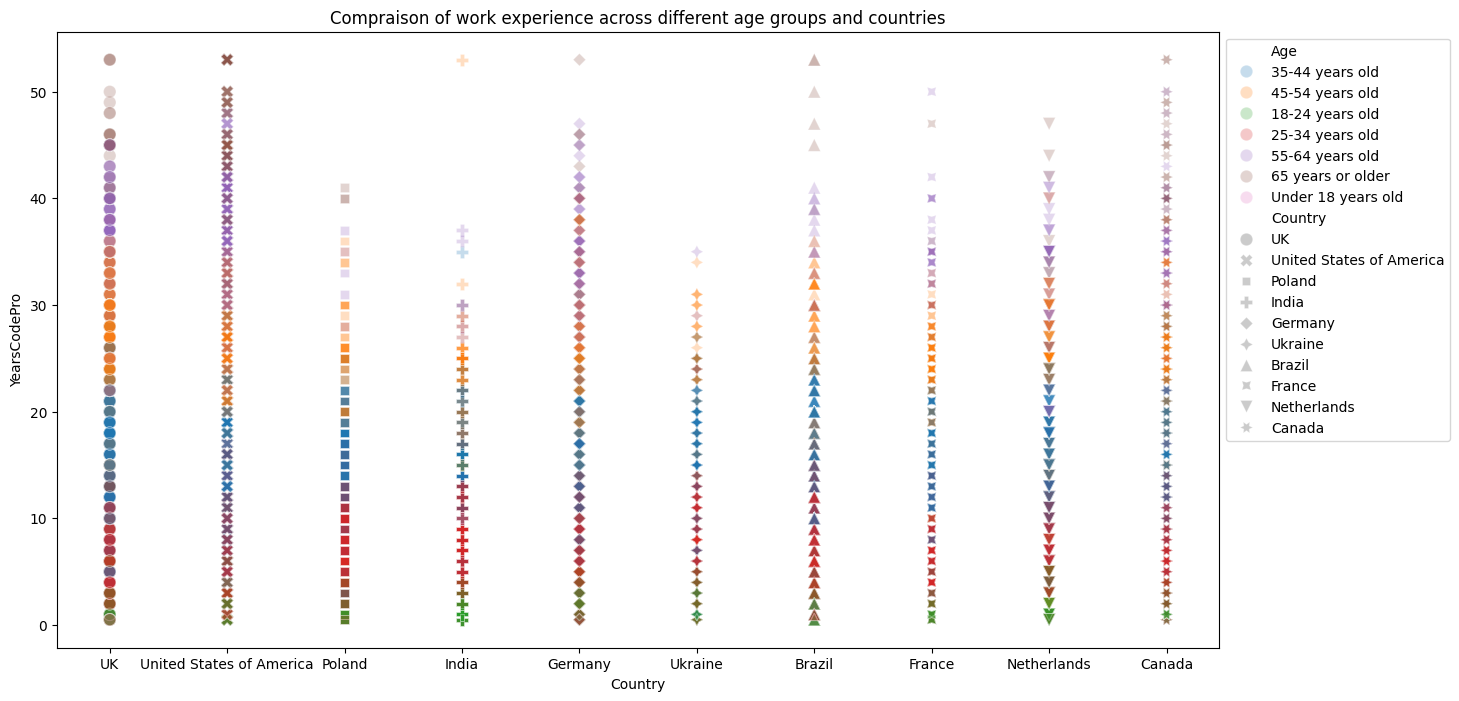

In [11]:
## Write your code here

c_age_exp=df.copy()

print('null values before cleaning',c_age_exp[['Country','YearsCodePro']].isnull().sum())
c_age_exp=c_age_exp.dropna(subset=['Country','YearsCodePro'], axis=0)
print('\n\nnull values after cleaning',c_age_exp[['Country','YearsCodePro']].isnull().sum())

top_10c=(c_age_exp.groupby('Country').size()
         .sort_values(ascending=False).head(10).index)

c_age_exp=c_age_exp[c_age_exp['Country'].isin(top_10c)]

c_age_exp=c_age_exp[c_age_exp['Age']!="Prefer not to say"]

c_age_exp['YearsCodePro']=c_age_exp['YearsCodePro'].replace({
    'Less than 1 year': 0.5
    ,'More than 50 years': 53
})

c_age_exp['YearsCodePro']=pd.to_numeric(c_age_exp['YearsCodePro'], errors='coerce')
c_age_exp = c_age_exp.dropna(subset=['YearsCodePro'], axis=0)

c_age_exp['Country']=c_age_exp['Country'].replace('United Kingdom of Great Britain and Northern Ireland','UK')

plt.figure(figsize=(15,8))
sns.scatterplot(data=c_age_exp
                ,x='Country'
                ,y='YearsCodePro'
                ,hue='Age'
                ,s=80
                ,alpha=0.25
                ,style='Country'
               )
plt.title('Compraison of work experience across different age groups and countries')
plt.legend(bbox_to_anchor=(1,1))
plt.show()

### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
